In [1]:
#Import Libraries for data Analysis and Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
# Read unemployment dataset into a DataFrame
Analysis = pd.read_csv('/content/drive/MyDrive/Unemployment in India.csv')

# Data Quick View
Analysis.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [3]:
# Here we go to Explore Dataset Structure

In [4]:
# Generate summary statistics of numerical columns
Analysis.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [5]:
# To Check Number of Rows and Columns
Analysis.shape

(768, 7)

In [6]:
# Respresenting Dataset Information
Analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [7]:
# Checking Missing values
Analysis.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [8]:
#Moving on Data Cleaning Process

In [9]:
# Remove extra spaces from column names
Analysis.columns = Analysis.columns.str.strip()

# Remove rows with missing values
Analysis.dropna(inplace=True)

# Check if any missing values remain
Analysis.isnull().sum()


,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Area,0


In [10]:
# Display dataset shape after cleaning
Analysis.shape

(740, 7)

In [11]:
Analysis.columns = Analysis.columns.str.strip()

# Strip whitespace from 'Date' column values
Analysis['Date'] = Analysis['Date'].str.strip()

# Convert Date column to datetime format, specifying the format to avoid UserWarning
Analysis['Date'] = pd.to_datetime(Analysis['Date'], format='%d-%m-%Y')

# Extract year and month for analysis
Analysis['Year'] = Analysis['Date'].dt.year
Analysis['Month'] = Analysis['Date'].dt.month

# Display updated dataset
Analysis.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,5
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,6
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,7
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019,8
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019,9


In [12]:
# Generate descriptive statistics
Analysis.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Year,Month
count,740,740.000000,7.400000e+02,740.000000,740.000000,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122,2019.418919,6.390541
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000,2019.000000,1.000000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500,2019.000000,4.000000
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000,2019.000000,6.000000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000,2020.000000,9.000000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000,2020.000000,12.000000
std,NaN,10.721298,8.087988e+06,8.111094,0.493716,3.235070


In [13]:
# Average Unemployment Rate by State
#Calculating Mean of Estimated Unemployment Rate (%) by grouping Region (States)
state_unemp = Analysis.groupby('Region')['Estimated Unemployment Rate (%)'].mean()
state_unemp

,Estimated Unemployment Rate (%)
Region,
Andhra Pradesh,7.477143
Assam,6.428077
Bihar,18.918214
Chandigarh,15.991667
Chhattisgarh,9.240357
Delhi,16.495357
Goa,9.274167
Gujarat,6.663929
Haryana,26.283214


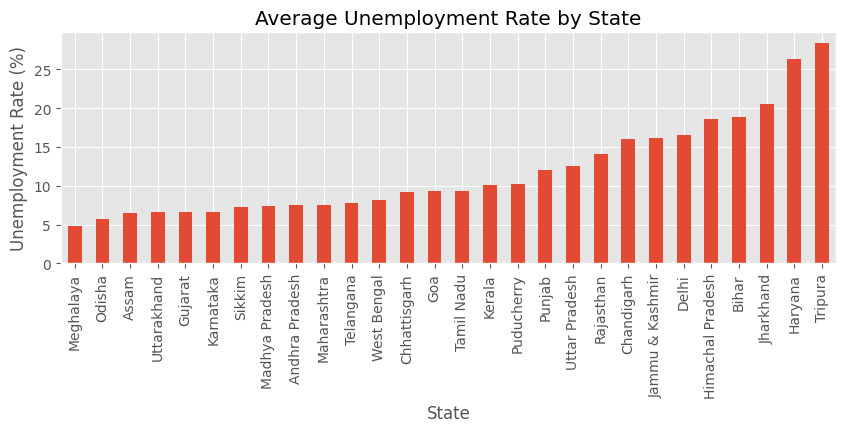

In [14]:
# Plot state-wise average unemployment
plt.figure(figsize=(10,3))
state_unemp.sort_values().plot(kind='bar')

plt.title('Average Unemployment Rate by State')
plt.xlabel('State')
plt.ylabel('Unemployment Rate (%)')
plt.show()

In [15]:
# Monthly Unemployment Trend
# Calculate average unemployment for each date
monthly = Analysis.groupby('Date')['Estimated Unemployment Rate (%)'].mean()
monthly

,Estimated Unemployment Rate (%)
Date,
2019-05-31,8.874259
2019-06-30,9.303333
2019-07-31,9.033889
2019-08-31,9.637925
2019-09-30,9.051731
2019-10-31,9.900909
2019-11-30,9.868364
2019-12-31,9.497358
2020-01-31,9.950755


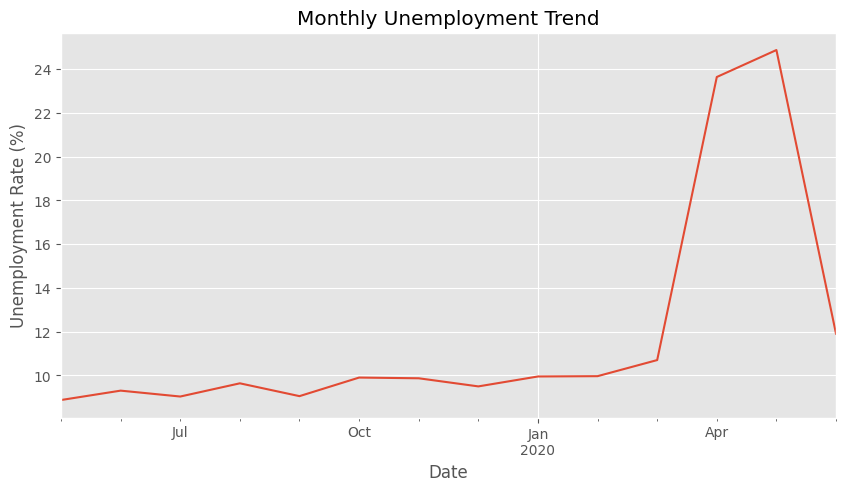

In [16]:
# Plot trend over time
plt.figure(figsize=(10,5))
monthly.plot()

plt.title('Monthly Unemployment Trend')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.show()

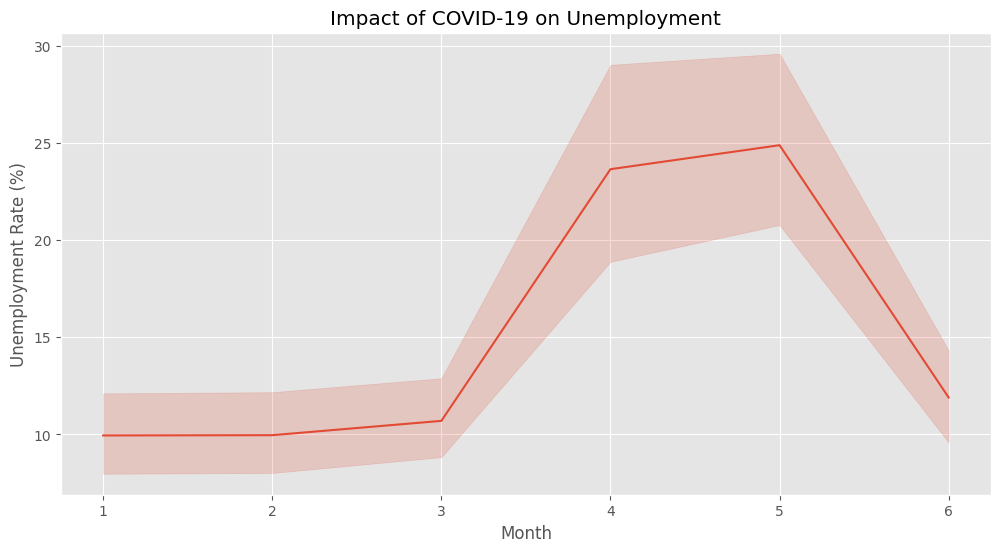

In [17]:
# Impact of COVID-19

# Filter records from year 2020
covid = Analysis[Analysis['Year'] == 2020]

# Visualize unemployment during COVID period
plt.figure(figsize=(12,6))
sns.lineplot(
    data=covid,
    x='Month',
    y='Estimated Unemployment Rate (%)'
)

plt.title('Impact of COVID-19 on Unemployment')
plt.xlabel('Month')
plt.ylabel('Unemployment Rate (%)')
plt.show()

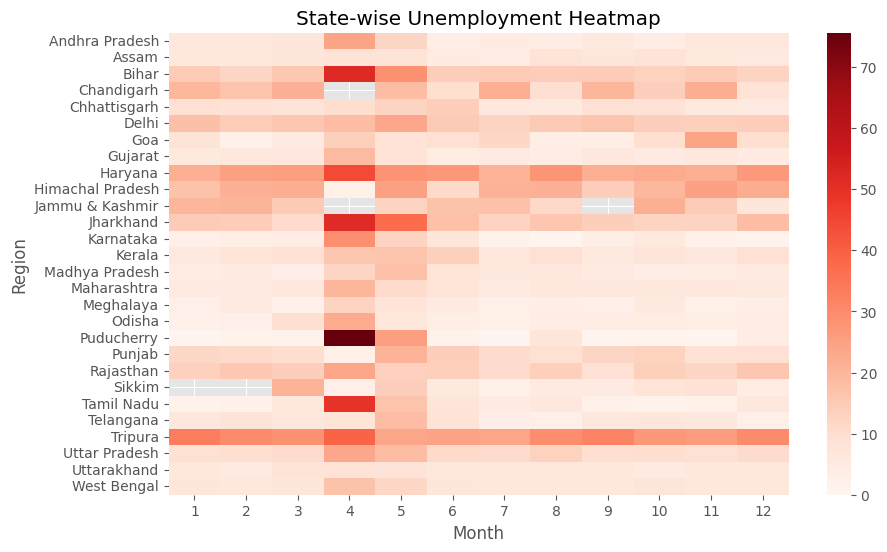

In [18]:
# State-wise Heatmap
# Create pivot table for heatmap visualization
pivot = Analysis.pivot_table(
    values='Estimated Unemployment Rate (%)',
    index='Region',
    columns='Month'
)

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap='Reds')

plt.title('State-wise Unemployment Heatmap')
plt.show()

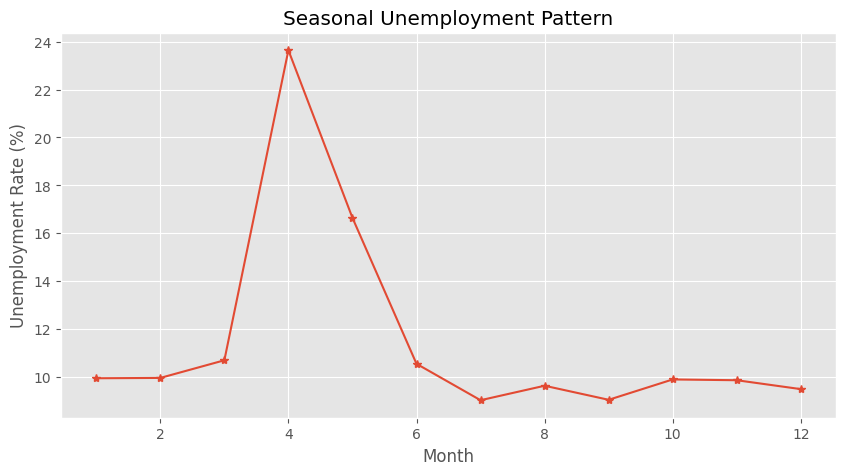

In [19]:
# Seasonal Trend Analysis
# Calculate monthly average unemployment rate
seasonal = Analysis.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

# Plot seasonal pattern
plt.figure(figsize=(10,5))
seasonal.plot(marker='*')

plt.title('Seasonal Unemployment Pattern')
plt.xlabel('Month')
plt.ylabel('Unemployment Rate (%)')
plt.show()

In [20]:
# Top 10 States with Highest Unemployment
# Find states with highest average unemployment
top_states = state_unemp.sort_values(ascending=False).head(10)
top_states

,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


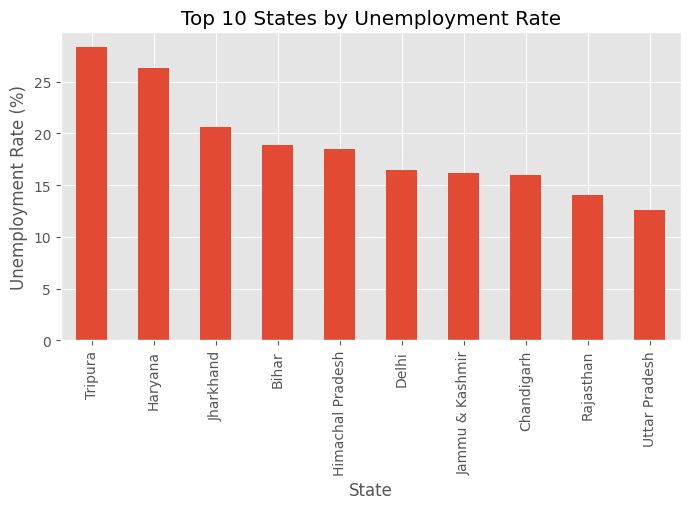

In [21]:
# Plot top 10 states
plt.figure(figsize=(8,4))
top_states.plot(kind='bar')

plt.title('Top 10 States by Unemployment Rate')
plt.xlabel('State')
plt.ylabel('Unemployment Rate (%)')
plt.show()

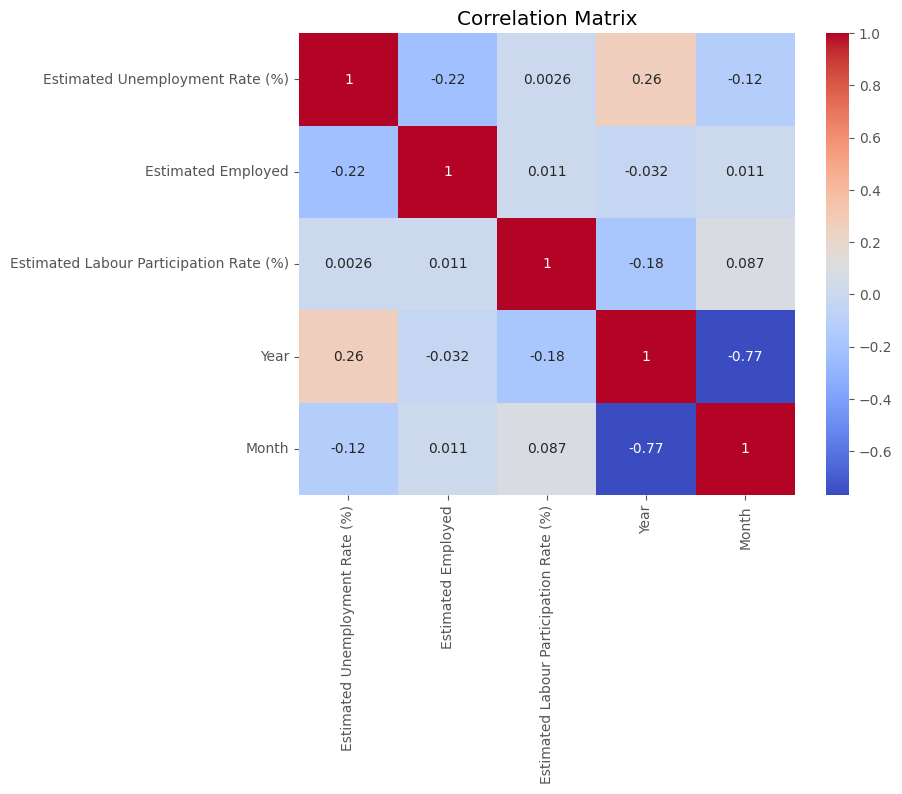

In [22]:
# Correlation Analysis

# Select numerical columns
numeric_Analysis = Analysis.select_dtypes(include=np.number)

# Compute correlation matrix
corr = numeric_Analysis.corr()

# Plot correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

In [23]:
# Display key observations
print("Key Insights:")
print("1. COVID-19 significantly increased unemployment rates.")
print("2. Peak unemployment occurred during lockdown months.")
print("3. Some states experienced much higher unemployment than others.")
print("4. Seasonal variations exist across months.")
print("5. Unemployment gradually declined after restrictions eased.")

Key Insights:
1. COVID-19 significantly increased unemployment rates.
2. Peak unemployment occurred during lockdown months.
3. Some states experienced much higher unemployment than others.
4. Seasonal variations exist across months.
5. Unemployment gradually declined after restrictions eased.
